In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/df_cleaned.csv')

In [ ]:
df.shape

(326327, 24)

In [ ]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON
0,201516622,2020-10-21,2020-10-18,18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203
1,201115217,2020-10-29,2020-07-07,14:00:00,11,Northeast,1133,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,121.0,YARD (RESIDENTIAL/BUSINESS),500.0,UNKNOWN WEAPON/OTHER WEAPON,AO,Adult Other,812.0,3000 ACRESITE ST,34.1107,-118.2589
2,240605846,2024-02-06,2020-06-20,00:01:00,6,Hollywood,657,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,812.0,1000 N RIDGEWOOD PL,34.0878,-118.3146
3,201820230,2020-11-08,2020-11-08,07:30:00,18,Southeast,1844,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,626.0,108TH ST,33.9383,-118.2652
4,201707577,2020-03-20,2020-03-20,13:20:00,17,Devonshire,1752,2,624,BATTERY - SIMPLE ASSAULT,...,210.0,RESTAURANT/FAST FOOD,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,624.0,20900 DEVONSHIRE ST,34.2572,-118.5885


In [ ]:
df['Status Desc'].value_counts()

,count
Status Desc,
Invest Cont,190391
Adult Other,78246
Adult Arrest,53924
Juv Arrest,2465
Juv Other,1299
UNK,2


In [ ]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format='%Y-%m-%d')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%Y-%m-%d')

In [ ]:
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%H:%M:%S').dt.time

In [ ]:
df['hour'] = pd.to_datetime(df['TIME OCC'], format='%H:%M:%S').dt.hour
df['day'] = df['DATE OCC'].dt.day_name()
df['month'] = df['DATE OCC'].dt.month
df['year'] = df['DATE OCC'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326327 entries, 0 to 326326
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DR_NO           326327 non-null  int64         
 1   Date Rptd       326327 non-null  datetime64[ns]
 2   DATE OCC        326327 non-null  datetime64[ns]
 3   TIME OCC        326327 non-null  object        
 4   AREA            326327 non-null  int64         
 5   AREA NAME       326327 non-null  object        
 6   Rpt Dist No     326327 non-null  int64         
 7   Part 1-2        326327 non-null  int64         
 8   Crm Cd          326327 non-null  int64         
 9   Crm Cd Desc     326327 non-null  object        
 10  Mocodes         326327 non-null  object        
 11  Vict Age        326327 non-null  int64         
 12  Vict Sex        326327 non-null  object        
 13  Vict Descent    326327 non-null  object        
 14  Premis Cd       326327 non-null  flo

# **statistical_analysis**

### Descriptive Statistical Analysis (Baseline Understanding)

#### Mean, Median, Mode

In [ ]:
# Victim Age
print('Victim Age - Mean:', df['Vict Age'].mean())
print('Victim Age - Median:', df['Vict Age'].median())
print('Victim Age - Mode:', df['Vict Age'].mode()[0])

Victim Age - Mean: 37.2645597820591
Victim Age - Median: 35.0
Victim Age - Mode: 35


In [ ]:
# Hourly Crime Distribution (using 'hour' column)
# Mean
print('Hourly Crime Distribution - Mean:', df['hour'].mean())
# Median
print('Hourly Crime Distribution - Median:', df['hour'].median())
# Mode
print('Hourly Crime Distribution - Mode:', df['hour'].mode()[0])

Hourly Crime Distribution - Mean: 13.267639514965051
Hourly Crime Distribution - Median: 14.0
Hourly Crime Distribution - Mode: 20


#### Variance & Standard Deviation

In [ ]:
# Crime variability over time (e.g., daily crime counts)
daily_crime_counts = df['DATE OCC'].value_counts().sort_index()
print(daily_crime_counts)
print('Daily Crime Counts - Variance:', daily_crime_counts.var())
print('Daily Crime Counts - Standard Deviation:', daily_crime_counts.std())

DATE OCC
2020-01-01    506
2020-01-02    184
2020-01-03    196
2020-01-04    221
2020-01-05    187
             ... 
2024-12-25      6
2024-12-27      6
2024-12-28      3
2024-12-29      1
2024-12-30      3
Name: count, Length: 1824, dtype: int64
Daily Crime Counts - Variance: 5133.474131408118
Daily Crime Counts - Standard Deviation: 71.64826677183558


#### Distribution Analysis (Skewness/Kurtosis)

In [ ]:
# Victim Age
print('Victim Age - Skewness:', df['Vict Age'].skew())
print('Victim Age - Kurtosis:', df['Vict Age'].kurt())

# Hourly crime distribution
print('Hourly Crime Distribution - Skewness:', df['hour'].skew())
print('Hourly Crime Distribution - Kurtosis:', df['hour'].kurt())

# Crime counts (using daily crime counts from previous step)
print('Daily Crime Counts - Skewness:', daily_crime_counts.skew())
print('Daily Crime Counts - Kurtosis:', daily_crime_counts.kurt())

Victim Age - Skewness: 0.6224178675892251
Victim Age - Kurtosis: 0.237661232353771
Hourly Crime Distribution - Skewness: -0.4487749673233421
Hourly Crime Distribution - Kurtosis: -0.8428831952142986
Daily Crime Counts - Skewness: -1.3685268222349354
Daily Crime Counts - Kurtosis: 1.414545394285545


### Association & Relationship Analysis

#### Correlation Analysis

In [ ]:
print('Correlation between Victim Age and Hour:', df['Vict Age'].corr(df['hour']))

Correlation between Victim Age and Hour: 0.005031950742087715


#### Cross-tabulation Analysis

In [ ]:
# Crime Type vs Area
crosstab_crime_area = pd.crosstab(df['Crm Cd Desc'], df['AREA NAME'])
print('Cross-tabulation: Crime Type vs Area\n', crosstab_crime_area.head())

# Crime Type vs Time
crosstab_crime_time = pd.crosstab(df['Crm Cd Desc'], df['hour'])
print('\nCross-tabulation: Crime Type vs Hour\n', crosstab_crime_time.head())

Cross-tabulation: Crime Type vs Area
 AREA NAME                                       77th Street  Central  \
Crm Cd Desc                                                            
ARSON                                                    61       73   
ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER             82      157   
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT         5907     4047   
ATTEMPTED ROBBERY                                       479      457   
BATTERY - SIMPLE ASSAULT                               4684     6804   

AREA NAME                                       Devonshire  Foothill  Harbor  \
Crm Cd Desc                                                                    
ARSON                                                   14        19      31   
ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER            15        51      26   
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT        1327      1739    2338   
ATTEMPTED ROBBERY                                      11

#### Cramér’s V

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Cramér's V for Crime Type vs Area
cramers_v_crime_area = cramers_v(df['Crm Cd Desc'], df['AREA NAME'])
print(f"Cramér's V for Crime Type vs Area: {cramers_v_crime_area:.4f}")

# Cramér's V for Crime Type vs Hour
cramers_v_crime_time = cramers_v(df['Crm Cd Desc'], df['hour'])
print(f"Cramér's V for Crime Type vs Hour: {cramers_v_crime_time:.4f}")

Cramér's V for Crime Type vs Area: 0.0867
Cramér's V for Crime Type vs Hour: 0.0484


### Hypothesis Testing (Statistical Significance)

#### Chi-Square Test

In [ ]:
from scipy.stats import chi2_contingency

# Chi-Square Test for Crime Type vs Area
crosstab_crime_area = pd.crosstab(df['Crm Cd Desc'], df['AREA NAME'])
chi2, p_val, _, _ = chi2_contingency(crosstab_crime_area)
print(f"Chi-Square Test: Crime Type vs Area - Chi2: {chi2:.2f}, P-value: {p_val:.4f}")

# Chi-Square Test for Crime Type vs Time of Day (hour)
crosstab_crime_hour = pd.crosstab(df['Crm Cd Desc'], df['hour'])
chi2, p_val, _, _ = chi2_contingency(crosstab_crime_hour)
print(f"Chi-Square Test: Crime Type vs Hour - Chi2: {chi2:.2f}, P-value: {p_val:.4f}")

Chi-Square Test: Crime Type vs Area - Chi2: 51476.32, P-value: 0.0000
Chi-Square Test: Crime Type vs Hour - Chi2: 20356.31, P-value: 0.0000


#### ANOVA

In [ ]:
from scipy.stats import f_oneway

# ANOVA to compare mean victim age across different crime types
# Due to the large number of crime types, we'll select a few top ones for demonstration
top_crime_types = df['Crm Cd Desc'].value_counts().head(5).index

# Prepare data for ANOVA
data_for_anova = []
for crime_type in top_crime_types:
    data_for_anova.append(df[df['Crm Cd Desc'] == crime_type]['Vict Age'].dropna())

# Perform ANOVA
if len(data_for_anova) > 1:
    f_stat, p_val = f_oneway(*data_for_anova)
    print(f"ANOVA (Top 5 Crime Types vs Victim Age) - F-statistic: {f_stat:.2f}, P-value: {p_val:.4f}")
else:
    print("Not enough groups to perform ANOVA effectively with selected crime types.")

ANOVA (Top 5 Crime Types vs Victim Age) - F-statistic: 1190.10, P-value: 0.0000


#### T-Test

In [ ]:
from scipy.stats import ttest_ind

# Example: Compare victim age in violent vs non-violent crimes
# (Assuming 'ASSAULT' and 'BATTERY' as violent, others as non-violent for simplicity)

violent_crimes = ['ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'BATTERY - SIMPLE ASSAULT']

victim_age_violent = df[df['Crm Cd Desc'].isin(violent_crimes)]['Vict Age'].dropna()
victim_age_non_violent = df[~df['Crm Cd Desc'].isin(violent_crimes)]['Vict Age'].dropna()

# Perform T-test
if not victim_age_violent.empty and not victim_age_non_violent.empty:
    t_stat, p_val = ttest_ind(victim_age_violent, victim_age_non_violent)
    print(f"T-Test (Victim Age in Violent vs Non-Violent Crimes) - T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")
else:
    print("Could not perform T-Test: One or both groups (violent/non-violent victim age) are empty.")

T-Test (Victim Age in Violent vs Non-Violent Crimes) - T-statistic: 66.24, P-value: 0.0000


### Temporal Statistical Analysis

#### Time Series Trend Analysis

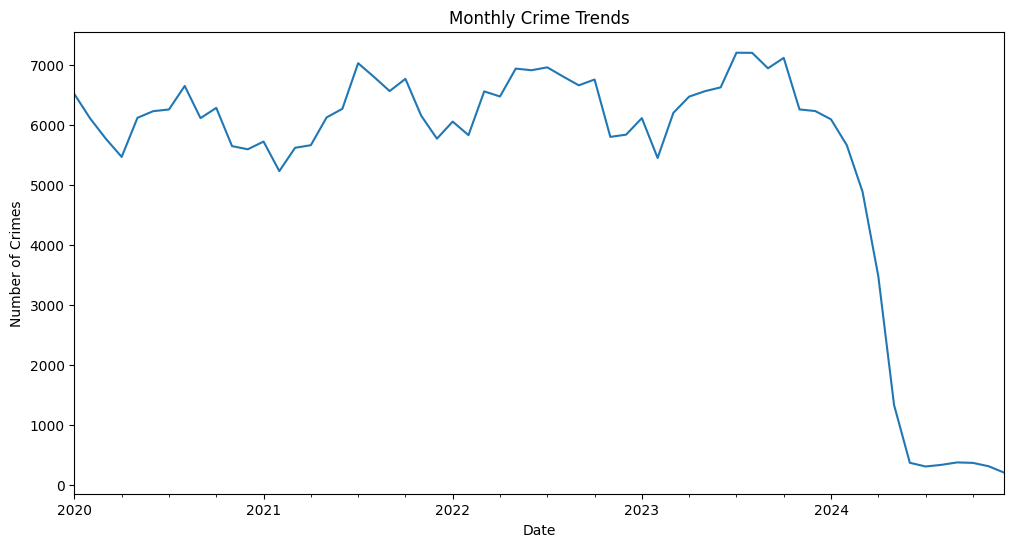

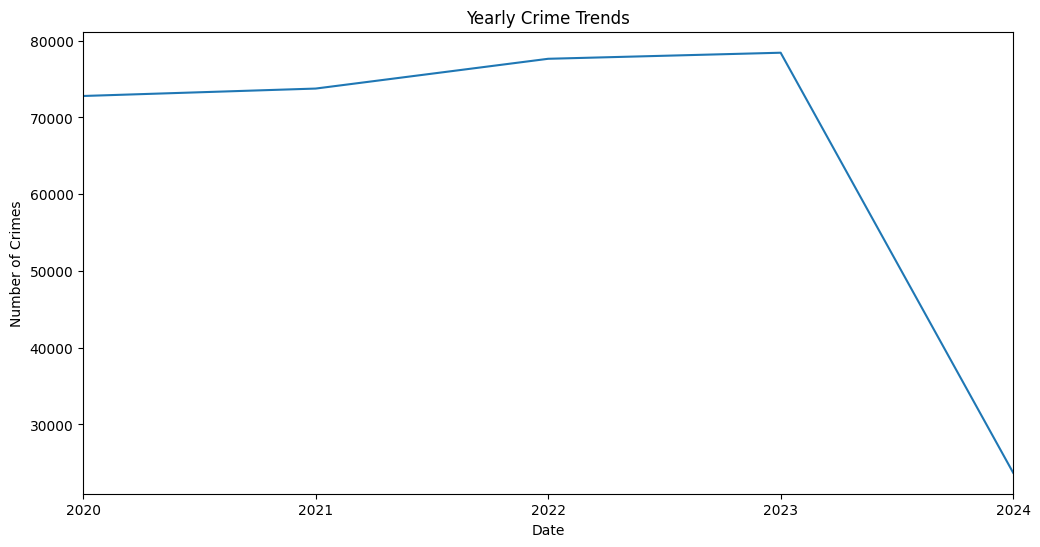

In [ ]:
# Monthly Crime Trends
monthly_crime_counts = df.groupby(df['DATE OCC'].dt.to_period('M')).size()
monthly_crime_counts.index = monthly_crime_counts.index.to_timestamp()
plt.figure(figsize=(12, 6))
monthly_crime_counts.plot()
plt.title('Monthly Crime Trends')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()

# Yearly Crime Trends
yearly_crime_counts = df.groupby(df['DATE OCC'].dt.to_period('Y')).size()
yearly_crime_counts.index = yearly_crime_counts.index.to_timestamp()
plt.figure(figsize=(12, 6))
yearly_crime_counts.plot()
plt.title('Yearly Crime Trends')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()

#### Moving Average Smoothing

/tmp/ipykernel_8537/92284675.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size()


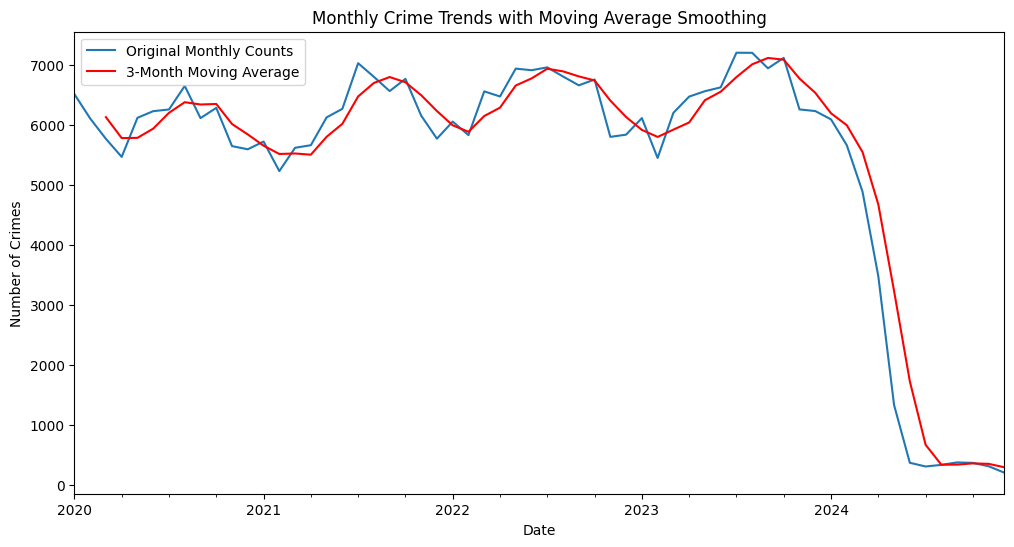

In [ ]:
monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size()

# Apply moving average (e.g., 3-month rolling mean)
moving_avg = monthly_crime_counts_resampled.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
monthly_crime_counts_resampled.plot(label='Original Monthly Counts')
moving_avg.plot(label='3-Month Moving Average', color='red')
plt.title('Monthly Crime Trends with Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.legend()
plt.show()

#### Seasonal Decomposition

/tmp/ipykernel_8537/3395836757.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size().fillna(0)


<Figure size 1400x800 with 0 Axes>

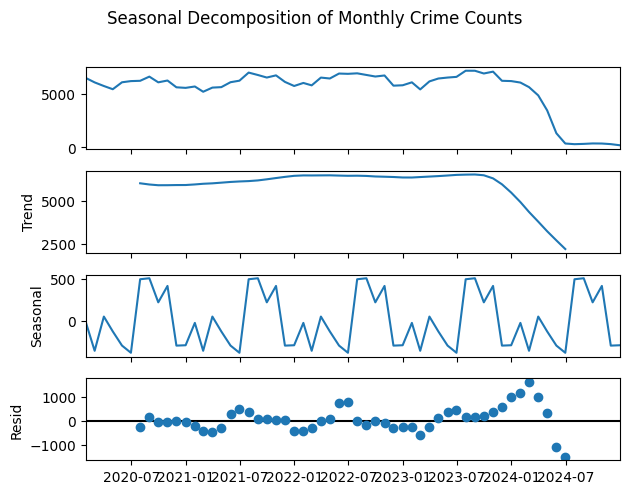

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the time series has sufficient data points for decomposition
# For monthly data, need at least 2 full cycles (e.g., 24 months for yearly seasonality)

# Re-index monthly_crime_counts_resampled to ensure proper frequency for decomposition
monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size().fillna(0)

# Check for minimum length for decomposition
if len(monthly_crime_counts_resampled) >= 24: # Assuming yearly seasonality (12 data points)
    decomposition = seasonal_decompose(monthly_crime_counts_resampled, model='additive', period=12) # Assuming yearly seasonality

    plt.figure(figsize=(14, 8))
    decomposition.plot()
    plt.suptitle('Seasonal Decomposition of Monthly Crime Counts', y=1.02) # Adjust suptitle position
    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough data points ({len(monthly_crime_counts_resampled)}) for seasonal decomposition. Requires at least 24 data points for yearly seasonality.")

### Crime Pattern Analysis

#### Conditional Probability (P(Crime Type | Time / Area))

In [ ]:
# P(Crime Type | Time)
# Select a specific hour, e.g., 20 (8 PM)
hour_of_interest = 20
crimes_at_hour = df[df['hour'] == hour_of_interest]

if not crimes_at_hour.empty:
    total_crimes_at_hour = len(crimes_at_hour)
    crime_type_counts_at_hour = crimes_at_hour['Crm Cd Desc'].value_counts()
    conditional_prob_time = crime_type_counts_at_hour / total_crimes_at_hour
    print(f"Top 5 Conditional Probabilities P(Crime Type | Hour = {hour_of_interest}):\n{conditional_prob_time.head()}")
else:
    print(f"No crimes recorded at hour {hour_of_interest}.")

# P(Crime Type | Area)
# Select a specific area, e.g., 'Central'
area_of_interest = 'Central'
crimes_in_area = df[df['AREA NAME'] == area_of_interest]

if not crimes_in_area.empty:
    total_crimes_in_area = len(crimes_in_area)
    crime_type_counts_in_area = crimes_in_area['Crm Cd Desc'].value_counts()
    conditional_prob_area = crime_type_counts_in_area / total_crimes_in_area
    print(f"\nTop 5 Conditional Probabilities P(Crime Type | Area = {area_of_interest}):\n{conditional_prob_area.head()}")
else:
    print(f"No crimes recorded in area {area_of_interest}.")

Top 5 Conditional Probabilities P(Crime Type | Hour = 20):
Crm Cd Desc
BATTERY - SIMPLE ASSAULT                          0.217746
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    0.166480
INTIMATE PARTNER - SIMPLE ASSAULT                 0.151612
ROBBERY                                           0.099281
CRIMINAL THREATS - NO WEAPON DISPLAYED            0.056115
Name: count, dtype: float64

Top 5 Conditional Probabilities P(Crime Type | Area = Central):
Crm Cd Desc
BATTERY - SIMPLE ASSAULT                          0.277036
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    0.164780
ROBBERY                                           0.108550
INTIMATE PARTNER - SIMPLE ASSAULT                 0.090106
BRANDISH WEAPON                                   0.046702
Name: count, dtype: float64


#### Co-occurrence Analysis (Weapon × Crime Type relationships)

In [ ]:
# Co-occurrence matrix for Weapon Desc and Crm Cd Desc
# Filter out 'UNKNOWN WEAPON/OTHER WEAPON' for more meaningful analysis if it's too dominant
df_filtered = df[df['Weapon Desc'] != 'UNKNOWN WEAPON/OTHER WEAPON'].copy()

if not df_filtered.empty:
    co_occurrence_matrix = pd.crosstab(df_filtered['Weapon Desc'], df_filtered['Crm Cd Desc'])
    print("Co-occurrence Matrix (Weapon Desc vs Crime Type):\n")
    display(co_occurrence_matrix.head())

    # To find strong relationships, we can normalize or look at specific cells
    # For example, what crime types are most associated with a 'KNIFE' weapon?
    if 'KNIFE WITH BLADE 6INCHES OR LESS' in co_occurrence_matrix.index:
        knife_crimes = co_occurrence_matrix.loc['KNIFE WITH BLADE 6INCHES OR LESS'].sort_values(ascending=False)
        print("\nTop 5 Crime Types when 'KNIFE WITH BLADE 6INCHES OR LESS' is used:\n")
        display(knife_crimes.head())
    else:
        print("\n'KNIFE WITH BLADE 6INCHES OR LESS' not found in weapon descriptions.")
else:
    print("No data available after filtering 'UNKNOWN WEAPON/OTHER WEAPON'.")

Co-occurrence Matrix (Weapon Desc vs Crime Type):



Crm Cd Desc,ARSON,ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",ATTEMPTED ROBBERY,BATTERY - SIMPLE ASSAULT,BATTERY ON A FIREFIGHTER,BATTERY POLICE (SIMPLE),BATTERY WITH SEXUAL CONTACT,"BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM",BIKE - STOLEN,...,UNAUTHORIZED COMPUTER ACCESS,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",VANDALISM - MISDEAMEANOR ($399 OR UNDER),VEHICLE - ATTEMPT STOLEN,VEHICLE - STOLEN,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)",VIOLATION OF COURT ORDER,VIOLATION OF RESTRAINING ORDER,VIOLATION OF TEMPORARY RESTRAINING ORDER,WEAPONS POSSESSION/BOMBING
Weapon Desc,,,,,,,,,,,,,,,,,,,,,
AIR PISTOL/REVOLVER/RIFLE/BB GUN,0,12,1198,39,12,0,0,0,0,0,...,0,49,22,0,0,0,0,0,0,1
ANTIQUE FIREARM,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ASSAULT WEAPON/UZI/AK47/ETC,0,0,24,4,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
AUTOMATIC WEAPON/SUB-MACHINE GUN,0,0,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AXE,0,1,135,6,1,0,0,0,0,0,...,0,18,3,0,0,0,1,0,0,0



Top 5 Crime Types when 'KNIFE WITH BLADE 6INCHES OR LESS' is used:



,KNIFE WITH BLADE 6INCHES OR LESS
Crm Cd Desc,
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",2716
BRANDISH WEAPON,2033
ROBBERY,1096
INTIMATE PARTNER - AGGRAVATED ASSAULT,416
ATTEMPTED ROBBERY,256


### Predictive Statistical Modeling

#### Logistic Regression (predict probability of violent crime)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Define violent crimes (using the same definition as in T-test)
violent_crimes = ['ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'BATTERY - SIMPLE ASSAULT']
df['is_violent'] = df['Crm Cd Desc'].isin(violent_crimes).astype(int)

# Select features for the model
# Using 'Vict Age', 'hour', 'LAT', 'LON' as numerical features
# One-hot encode 'Vict Sex' and 'AREA NAME' (simplified for demonstration)
features = ['Vict Age', 'hour', 'LAT', 'LON']

X = df[features]
y = df['is_violent']

# Drop rows with NaN values if any (though earlier cleaning should have handled this)
X = X.dropna()
y = y.loc[X.index] # Ensure y aligns with X after dropping NaNs

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model for Violent Crime Prediction:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))

Logistic Regression Model for Violent Crime Prediction:
Accuracy: 0.6104
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.96      0.75     59419
           1       0.53      0.07      0.12     38480

    accuracy                           0.61     97899
   macro avg       0.57      0.52      0.44     97899
weighted avg       0.58      0.61      0.50     97899



### Anomaly & Risk Analysis

#### Z-Score Analysis (detect abnormal spikes in daily crime)

Anomalies detected using Z-Score (Daily Crime Counts):
Threshold: |Z-Score| > 3
    DATE OCC  Crime_Count   Z_Score
0 2020-01-01          506  4.566508


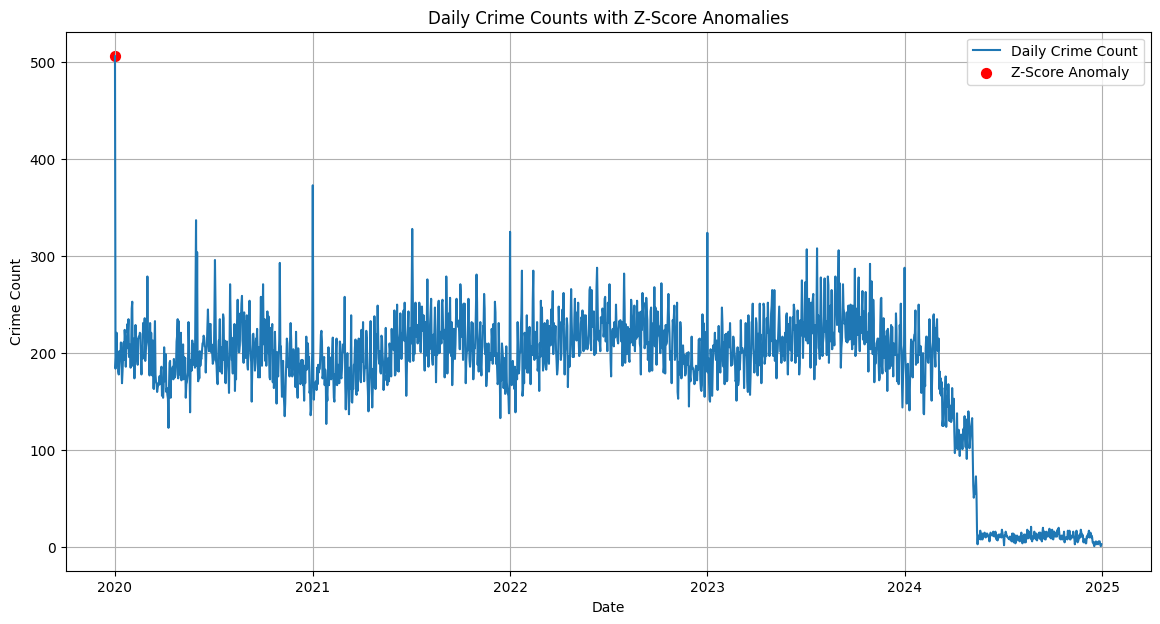

In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for daily crime counts
daily_crime_counts = df['DATE OCC'].value_counts().sort_index()
daily_crime_counts_df = daily_crime_counts.reset_index()
daily_crime_counts_df.columns = ['DATE OCC', 'Crime_Count']

daily_crime_counts_df['Z_Score'] = zscore(daily_crime_counts_df['Crime_Count'])

# Define a threshold for anomalies (e.g., Z-score > 3 or < -3)
anomaly_threshold = 3
anomalies_zscore = daily_crime_counts_df[
    (daily_crime_counts_df['Z_Score'] > anomaly_threshold) |
    (daily_crime_counts_df['Z_Score'] < -anomaly_threshold)
]

print("Anomalies detected using Z-Score (Daily Crime Counts):")
print(f"Threshold: |Z-Score| > {anomaly_threshold}")
if not anomalies_zscore.empty:
    print(anomalies_zscore)
else:
    print("No significant anomalies detected.")

# Plotting Z-scores over time
plt.figure(figsize=(14, 7))
plt.plot(daily_crime_counts_df['DATE OCC'], daily_crime_counts_df['Crime_Count'], label='Daily Crime Count')
plt.scatter(anomalies_zscore['DATE OCC'], anomalies_zscore['Crime_Count'], color='red', s=50, label='Z-Score Anomaly')
plt.title('Daily Crime Counts with Z-Score Anomalies')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.show()

#### IQR Method (outliers in victim age or time distribution)

In [ ]:
# Outliers in Victim Age using IQR Method
Q1_age = df['Vict Age'].quantile(0.25)
Q3_age = df['Vict Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

outliers_age = df[(df['Vict Age'] < lower_bound_age) | (df['Vict Age'] > upper_bound_age)]

print("Outliers in Victim Age using IQR Method:")
print(f"Lower Bound: {lower_bound_age:.2f}, Upper Bound: {upper_bound_age:.2f}")
if not outliers_age.empty:
    print(f"Number of Victim Age Outliers: {len(outliers_age)}")
    print(outliers_age[['Vict Age']].head())
else:
    print("No significant outliers in Victim Age detected.")

# Outliers in Hourly Crime Distribution using IQR Method (example)
Q1_hour = df['hour'].quantile(0.25)
Q3_hour = df['hour'].quantile(0.75)
IQR_hour = Q3_hour - Q1_hour

lower_bound_hour = Q1_hour - 1.5 * IQR_hour
upper_bound_hour = Q3_hour + 1.5 * IQR_hour

outliers_hour = df[(df['hour'] < lower_bound_hour) | (df['hour'] > upper_bound_hour)]

print("\nOutliers in Hourly Crime Distribution using IQR Method:")
print(f"Lower Bound: {lower_bound_hour:.2f}, Upper Bound: {upper_bound_hour:.2f}")
if not outliers_hour.empty:
    print(f"Number of Hourly Crime Outliers: {len(outliers_hour)}")
    print(outliers_hour[['hour']].head())
else:
    print("No significant outliers in Hourly Crime Distribution detected.")

Outliers in Victim Age using IQR Method:
Lower Bound: -1.50, Upper Bound: 74.50
Number of Victim Age Outliers: 4348
     Vict Age
89         79
147        96
193        77
302        80
332        75

Outliers in Hourly Crime Distribution using IQR Method:
Lower Bound: -6.00, Upper Bound: 34.00
No significant outliers in Hourly Crime Distribution detected.


#### Classification Models (Random Forest / Decision Trees for crime type prediction)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# For simplicity, let's predict the top 5 crime types
top_5_crime_types = df['Crm Cd Desc'].value_counts().head(5).index.tolist()
df_filtered_crimes = df[df['Crm Cd Desc'].isin(top_5_crime_types)].copy()

# Encode the target variable 'Crm Cd Desc'
le = LabelEncoder()
df_filtered_crimes['Crm_Type_Encoded'] = le.fit_transform(df_filtered_crimes['Crm Cd Desc'])

# Select features (using numerical features. For a more robust model, include one-hot encoded categorical features)
features_clf = ['Vict Age', 'hour', 'LAT', 'LON']
X_clf = df_filtered_crimes[features_clf]
y_clf = df_filtered_crimes['Crm_Type_Encoded']

# Handle potential NaNs
X_clf = X_clf.dropna()
y_clf = y_clf.loc[X_clf.index]

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Initialize and train a Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_rf = rf_model.predict(X_test_clf)

# Evaluate the model
print("Random Forest Classifier for Crime Type Prediction:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rf):.4f}")
print("Classification Report:\n", classification_report(y_test_clf, y_pred_rf, target_names=le.classes_))

Random Forest Classifier for Crime Type Prediction:
Accuracy: 0.3605
Classification Report:
                                                 precision    recall  f1-score   support

ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.30      0.29      0.30     15919
                      BATTERY - SIMPLE ASSAULT       0.42      0.54      0.47     22482
        CRIMINAL THREATS - NO WEAPON DISPLAYED       0.16      0.07      0.10      5678
             INTIMATE PARTNER - SIMPLE ASSAULT       0.34      0.34      0.34     14073
                                       ROBBERY       0.36      0.25      0.29      9664

                                      accuracy                           0.36     67816
                                     macro avg       0.32      0.30      0.30     67816
                                  weighted avg       0.34      0.36      0.35     67816



#### Linear Regression (predict crime count trends)

Linear Regression Model for Crime Count Trends:
Mean Squared Error: 3883.46
R-squared: 0.2882


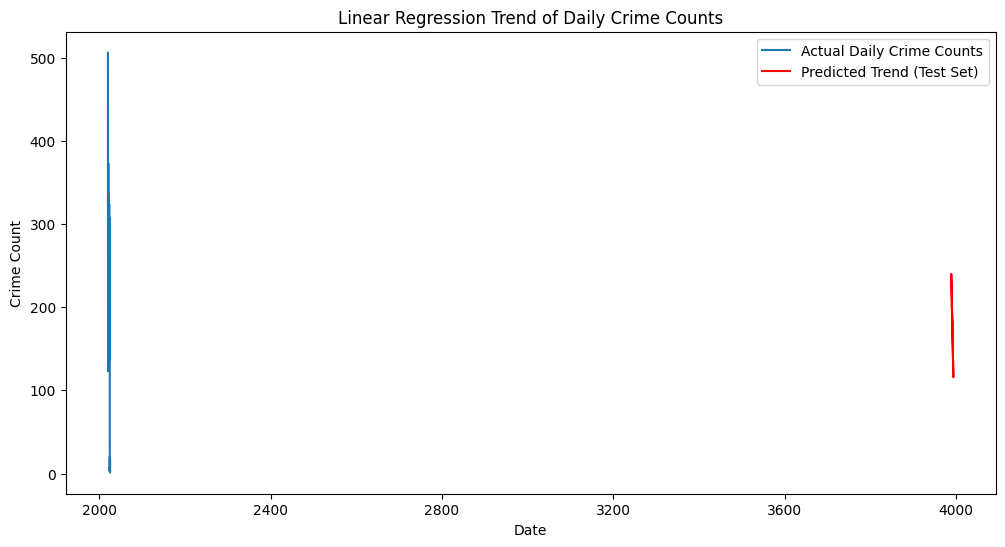

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data for Linear Regression (e.g., predicting daily crime counts over time)
# We'll use the 'daily_crime_counts' Series from earlier

time_series_df = pd.DataFrame({
    'Date': daily_crime_counts.index,
    'Crime_Count': daily_crime_counts.values
})

time_series_df['Ordinal_Date'] = time_series_df['Date'].apply(lambda x: x.toordinal())

X_lin = time_series_df[['Ordinal_Date']]
y_lin = time_series_df['Crime_Count']

# Split data into training and testing sets
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.3, random_state=42)

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_lin, y_train_lin)

# Make predictions
y_pred_lin_reg = lin_reg_model.predict(X_test_lin)

# Evaluate the model
print("Linear Regression Model for Crime Count Trends:")
print(f"Mean Squared Error: {mean_squared_error(y_test_lin, y_pred_lin_reg):.2f}")
print(f"R-squared: {r2_score(y_test_lin, y_pred_lin_reg):.4f}")

# Plotting the trend
plt.figure(figsize=(12, 6))
plt.plot(time_series_df['Date'], time_series_df['Crime_Count'], label='Actual Daily Crime Counts')
plt.plot(X_test_lin['Ordinal_Date'], y_pred_lin_reg, color='red', label='Predicted Trend (Test Set)')
plt.title('Linear Regression Trend of Daily Crime Counts')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.show()

### Predictive Statistical Modeling

#### Logistic Regression (predict probability of violent crime)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Define violent crimes (using the same definition as in T-test)
violent_crimes = ['ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'BATTERY - SIMPLE ASSAULT']
df['is_violent'] = df['Crm Cd Desc'].isin(violent_crimes).astype(int)

# Select features for the model
# Using 'Vict Age', 'hour', 'LAT', 'LON' as numerical features
# One-hot encode 'Vict Sex' and 'AREA NAME' (simplified for demonstration)
features = ['Vict Age', 'hour', 'LAT', 'LON']

X = df[features]
y = df['is_violent']

# Drop rows with NaN values if any (though earlier cleaning should have handled this)
X = X.dropna()
y = y.loc[X.index] # Ensure y aligns with X after dropping NaNs

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model for Violent Crime Prediction:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))

Logistic Regression Model for Violent Crime Prediction:
Accuracy: 0.6104
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.96      0.75     59419
           1       0.53      0.07      0.12     38480

    accuracy                           0.61     97899
   macro avg       0.57      0.52      0.44     97899
weighted avg       0.58      0.61      0.50     97899



### Predictive Statistical Modeling

#### Logistic Regression (predict probability of violent crime)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Define violent crimes (using the same definition as in T-test)
violent_crimes = ['ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'BATTERY - SIMPLE ASSAULT']
df['is_violent'] = df['Crm Cd Desc'].isin(violent_crimes).astype(int)

# Select features for the model
# Using 'Vict Age', 'hour', 'LAT', 'LON' as numerical features
# One-hot encode 'Vict Sex' and 'AREA NAME' (simplified for demonstration)
features = ['Vict Age', 'hour', 'LAT', 'LON']

X = df[features]
y = df['is_violent']

# Drop rows with NaN values if any (though earlier cleaning should have handled this)
X = X.dropna()
y = y.loc[X.index] # Ensure y aligns with X after dropping NaNs

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model for Violent Crime Prediction:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg))

Logistic Regression Model for Violent Crime Prediction:
Accuracy: 0.6104
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.96      0.75     59419
           1       0.53      0.07      0.12     38480

    accuracy                           0.61     97899
   macro avg       0.57      0.52      0.44     97899
weighted avg       0.58      0.61      0.50     97899



#### Linear Regression (predict crime count trends)

Linear Regression Model for Crime Count Trends:
Mean Squared Error: 3883.46
R-squared: 0.2882


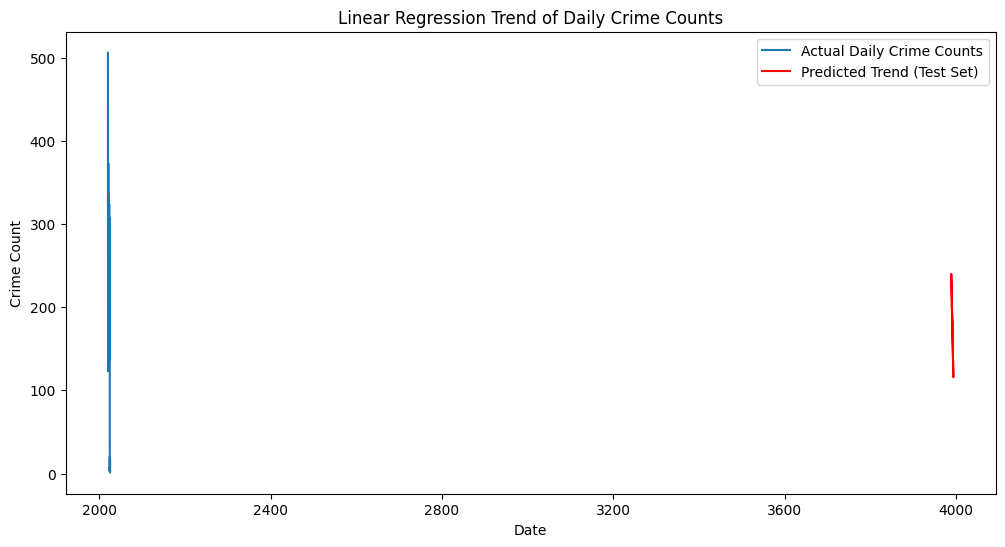

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data for Linear Regression (e.g., predicting daily crime counts over time)
# We'll use the 'daily_crime_counts' Series from earlier

time_series_df = pd.DataFrame({
    'Date': daily_crime_counts.index,
    'Crime_Count': daily_crime_counts.values
})

time_series_df['Ordinal_Date'] = time_series_df['Date'].apply(lambda x: x.toordinal())

X_lin = time_series_df[['Ordinal_Date']]
y_lin = time_series_df['Crime_Count']

# Split data into training and testing sets
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.3, random_state=42)

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_lin, y_train_lin)

# Make predictions
y_pred_lin_reg = lin_reg_model.predict(X_test_lin)

# Evaluate the model
print("Linear Regression Model for Crime Count Trends:")
print(f"Mean Squared Error: {mean_squared_error(y_test_lin, y_pred_lin_reg):.2f}")
print(f"R-squared: {r2_score(y_test_lin, y_pred_lin_reg):.4f}")

# Plotting the trend
plt.figure(figsize=(12, 6))
plt.plot(time_series_df['Date'], time_series_df['Crime_Count'], label='Actual Daily Crime Counts')
plt.plot(X_test_lin['Ordinal_Date'], y_pred_lin_reg, color='red', label='Predicted Trend (Test Set)')
plt.title('Linear Regression Trend of Daily Crime Counts')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.show()

#### Classification Models (Random Forest / Decision Trees for crime type prediction)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# For simplicity, let's predict the top 5 crime types
top_5_crime_types = df['Crm Cd Desc'].value_counts().head(5).index.tolist()
df_filtered_crimes = df[df['Crm Cd Desc'].isin(top_5_crime_types)].copy()

# Encode the target variable 'Crm Cd Desc'
le = LabelEncoder()
df_filtered_crimes['Crm_Type_Encoded'] = le.fit_transform(df_filtered_crimes['Crm Cd Desc'])

# Select features (using numerical and some encoded categorical features)
features_clf = ['Vict Age', 'hour', 'LAT', 'LON']
X_clf = df_filtered_crimes[features_clf]
y_clf = df_filtered_crimes['Crm_Type_Encoded']

# Handle potential NaNs
X_clf = X_clf.dropna()
y_clf = y_clf.loc[X_clf.index]

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Initialize and train a Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_rf = rf_model.predict(X_test_clf)

# Evaluate the model
print("Random Forest Classifier for Crime Type Prediction:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rf):.4f}")
print("Classification Report:\n", classification_report(y_test_clf, y_pred_rf, target_names=le.classes_))

Random Forest Classifier for Crime Type Prediction:
Accuracy: 0.3605
Classification Report:
                                                 precision    recall  f1-score   support

ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.30      0.29      0.30     15919
                      BATTERY - SIMPLE ASSAULT       0.42      0.54      0.47     22482
        CRIMINAL THREATS - NO WEAPON DISPLAYED       0.16      0.07      0.10      5678
             INTIMATE PARTNER - SIMPLE ASSAULT       0.34      0.34      0.34     14073
                                       ROBBERY       0.36      0.25      0.29      9664

                                      accuracy                           0.36     67816
                                     macro avg       0.32      0.30      0.30     67816
                                  weighted avg       0.34      0.36      0.35     67816



### Anomaly & Risk Analysis

#### Z-Score Analysis (detect abnormal spikes in daily crime)

Anomalies detected using Z-Score (Daily Crime Counts):
Threshold: |Z-Score| > 3
    DATE OCC  Crime_Count   Z_Score
0 2020-01-01          506  4.566508


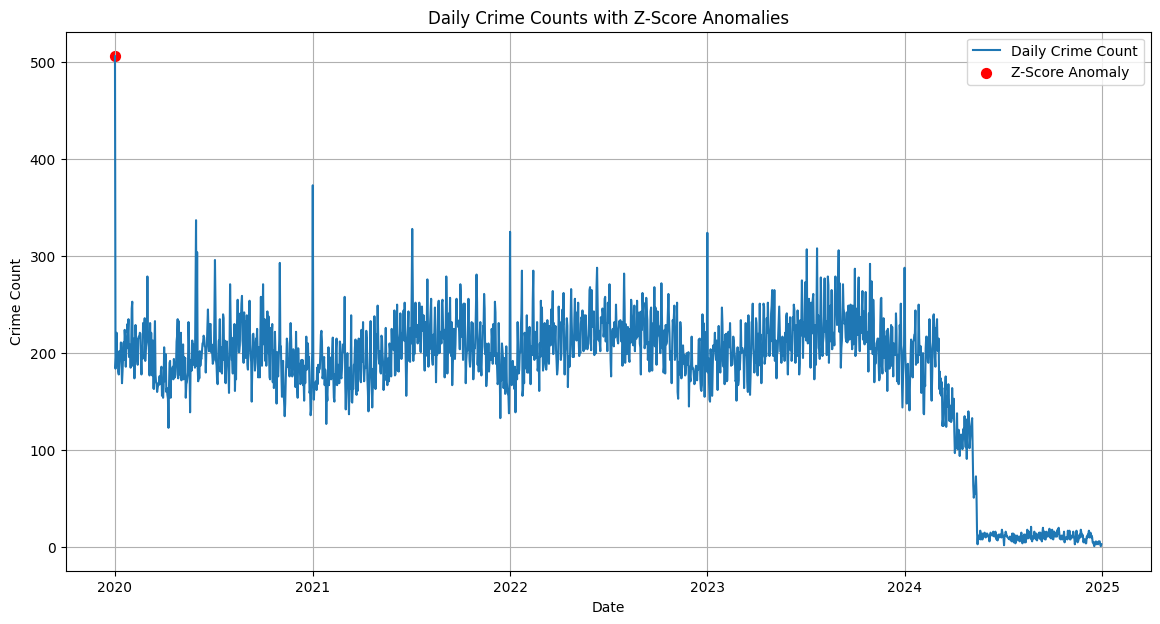

In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for daily crime counts
daily_crime_counts = df['DATE OCC'].value_counts().sort_index()
daily_crime_counts_df = daily_crime_counts.reset_index()
daily_crime_counts_df.columns = ['DATE OCC', 'Crime_Count']

daily_crime_counts_df['Z_Score'] = zscore(daily_crime_counts_df['Crime_Count'])

# Define a threshold for anomalies (e.g., Z-score > 3 or < -3)
anomaly_threshold = 3
anomalies_zscore = daily_crime_counts_df[
    (daily_crime_counts_df['Z_Score'] > anomaly_threshold) |
    (daily_crime_counts_df['Z_Score'] < -anomaly_threshold)
]

print("Anomalies detected using Z-Score (Daily Crime Counts):")
print(f"Threshold: |Z-Score| > {anomaly_threshold}")
if not anomalies_zscore.empty:
    print(anomalies_zscore)
else:
    print("No significant anomalies detected.")

# Plotting Z-scores over time
plt.figure(figsize=(14, 7))
plt.plot(daily_crime_counts_df['DATE OCC'], daily_crime_counts_df['Crime_Count'], label='Daily Crime Count')
plt.scatter(anomalies_zscore['DATE OCC'], anomalies_zscore['Crime_Count'], color='red', s=50, label='Z-Score Anomaly')
plt.title('Daily Crime Counts with Z-Score Anomalies')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.show()

#### IQR Method (outliers in victim age or time distribution)

In [ ]:
# Outliers in Victim Age using IQR Method
Q1_age = df['Vict Age'].quantile(0.25)
Q3_age = df['Vict Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

outliers_age = df[(df['Vict Age'] < lower_bound_age) | (df['Vict Age'] > upper_bound_age)]

print("Outliers in Victim Age using IQR Method:")
print(f"Lower Bound: {lower_bound_age:.2f}, Upper Bound: {upper_bound_age:.2f}")
if not outliers_age.empty:
    print(f"Number of Victim Age Outliers: {len(outliers_age)}")
    print(outliers_age[['Vict Age']].head())
else:
    print("No significant outliers in Victim Age detected.")

# Outliers in Hourly Crime Distribution using IQR Method (example)
Q1_hour = df['hour'].quantile(0.25)
Q3_hour = df['hour'].quantile(0.75)
IQR_hour = Q3_hour - Q1_hour

lower_bound_hour = Q1_hour - 1.5 * IQR_hour
upper_bound_hour = Q3_hour + 1.5 * IQR_hour

outliers_hour = df[(df['hour'] < lower_bound_hour) | (df['hour'] > upper_bound_hour)]

print("\nOutliers in Hourly Crime Distribution using IQR Method:")
print(f"Lower Bound: {lower_bound_hour:.2f}, Upper Bound: {upper_bound_hour:.2f}")
if not outliers_hour.empty:
    print(f"Number of Hourly Crime Outliers: {len(outliers_hour)}")
    print(outliers_hour[['hour']].head())
else:
    print("No significant outliers in Hourly Crime Distribution detected.")

Outliers in Victim Age using IQR Method:
Lower Bound: -1.50, Upper Bound: 74.50
Number of Victim Age Outliers: 4348
     Vict Age
89         79
147        96
193        77
302        80
332        75

Outliers in Hourly Crime Distribution using IQR Method:
Lower Bound: -6.00, Upper Bound: 34.00
No significant outliers in Hourly Crime Distribution detected.


### Temporal Statistical Analysis

#### Time Series Trend Analysis

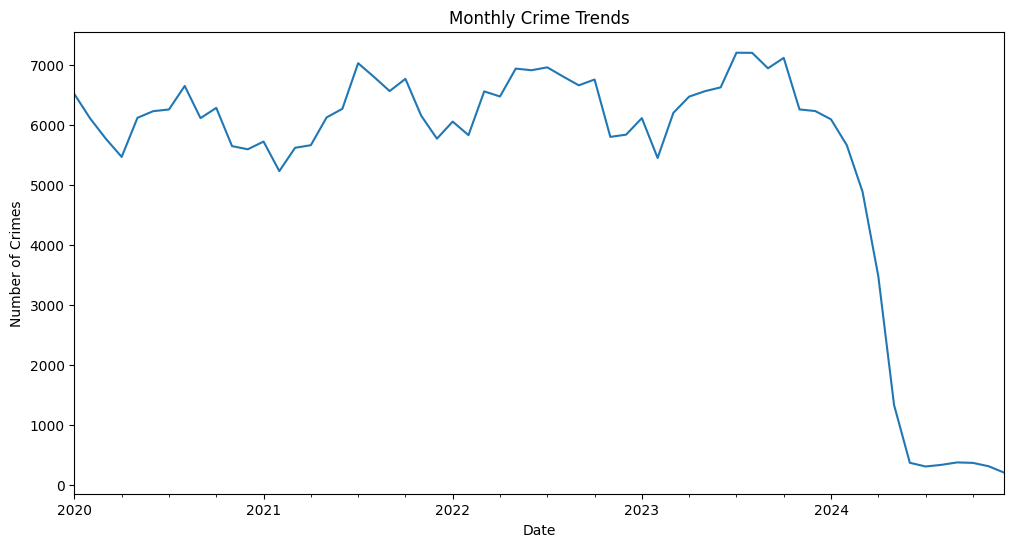

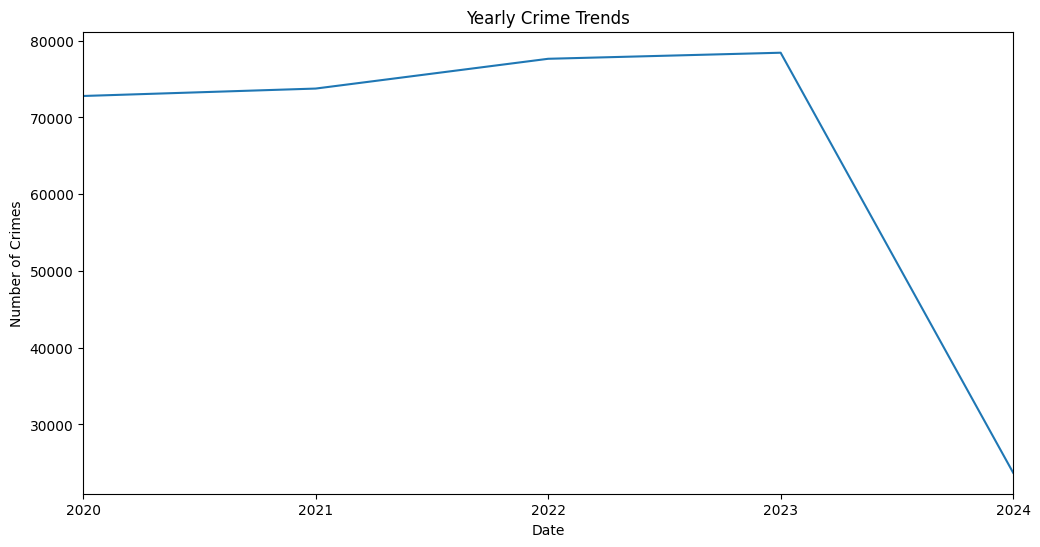

In [ ]:
# Monthly Crime Trends
monthly_crime_counts = df.groupby(df['DATE OCC'].dt.to_period('M')).size()
monthly_crime_counts.index = monthly_crime_counts.index.to_timestamp()
plt.figure(figsize=(12, 6))
monthly_crime_counts.plot()
plt.title('Monthly Crime Trends')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()

# Yearly Crime Trends
yearly_crime_counts = df.groupby(df['DATE OCC'].dt.to_period('Y')).size()
yearly_crime_counts.index = yearly_crime_counts.index.to_timestamp()
plt.figure(figsize=(12, 6))
yearly_crime_counts.plot()
plt.title('Yearly Crime Trends')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()

#### Moving Average Smoothing

/tmp/ipykernel_8537/92284675.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size()


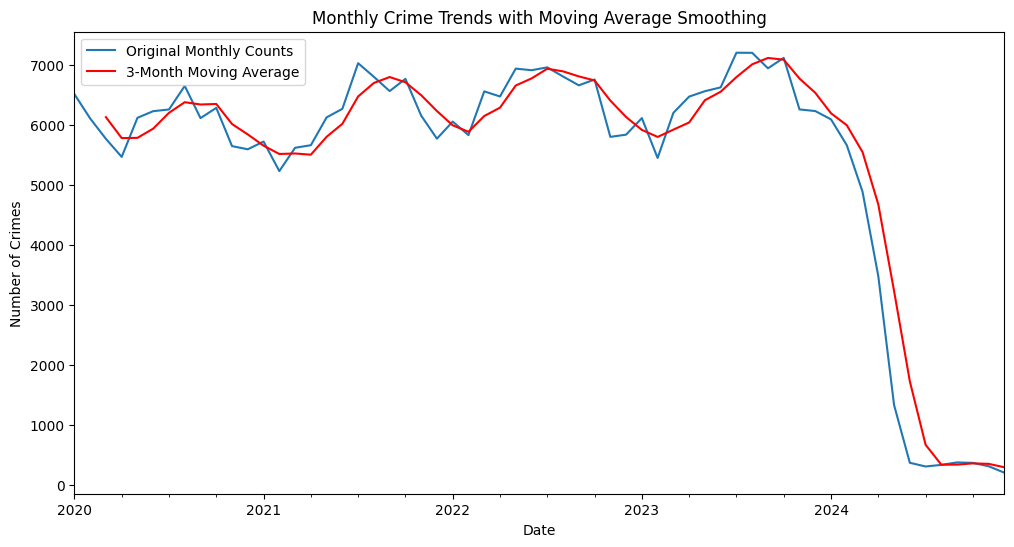

In [ ]:
monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size()

# Apply moving average (e.g., 3-month rolling mean)
moving_avg = monthly_crime_counts_resampled.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
monthly_crime_counts_resampled.plot(label='Original Monthly Counts')
moving_avg.plot(label='3-Month Moving Average', color='red')
plt.title('Monthly Crime Trends with Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.legend()
plt.show()

#### Seasonal Decomposition

/tmp/ipykernel_8537/3395836757.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size().fillna(0)


<Figure size 1400x800 with 0 Axes>

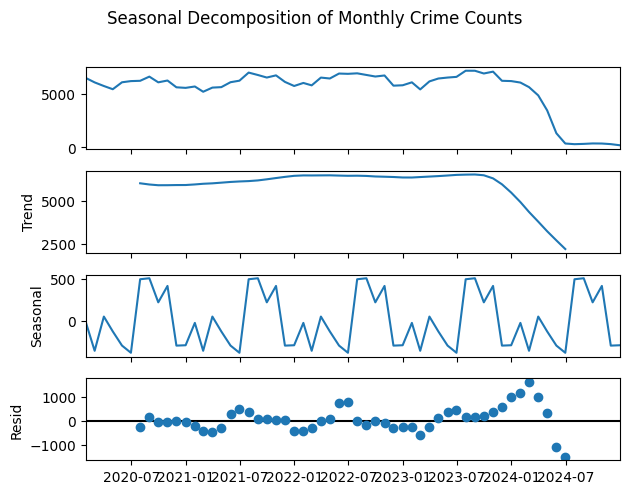

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the time series has sufficient data points for decomposition
# For monthly data, need at least 2 full cycles (e.g., 24 months for yearly seasonality)

# Re-index monthly_crime_counts_resampled to ensure proper frequency for decomposition
monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size().fillna(0)

# Check for minimum length for decomposition
if len(monthly_crime_counts_resampled) >= 24: # Assuming yearly seasonality (12 data points)
    decomposition = seasonal_decompose(monthly_crime_counts_resampled, model='additive', period=12) # Assuming yearly seasonality

    plt.figure(figsize=(14, 8))
    decomposition.plot()
    plt.suptitle('Seasonal Decomposition of Monthly Crime Counts', y=1.02) # Adjust suptitle position
    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough data points ({len(monthly_crime_counts_resampled)}) for seasonal decomposition. Requires at least 24 data points for yearly seasonality.")

### Temporal Statistical Analysis

#### Time Series Trend Analysis

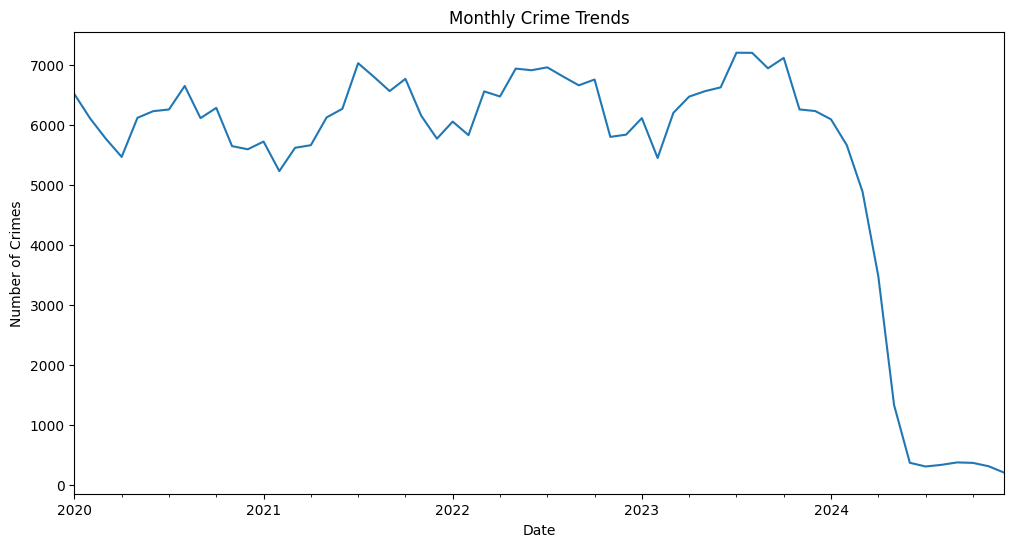

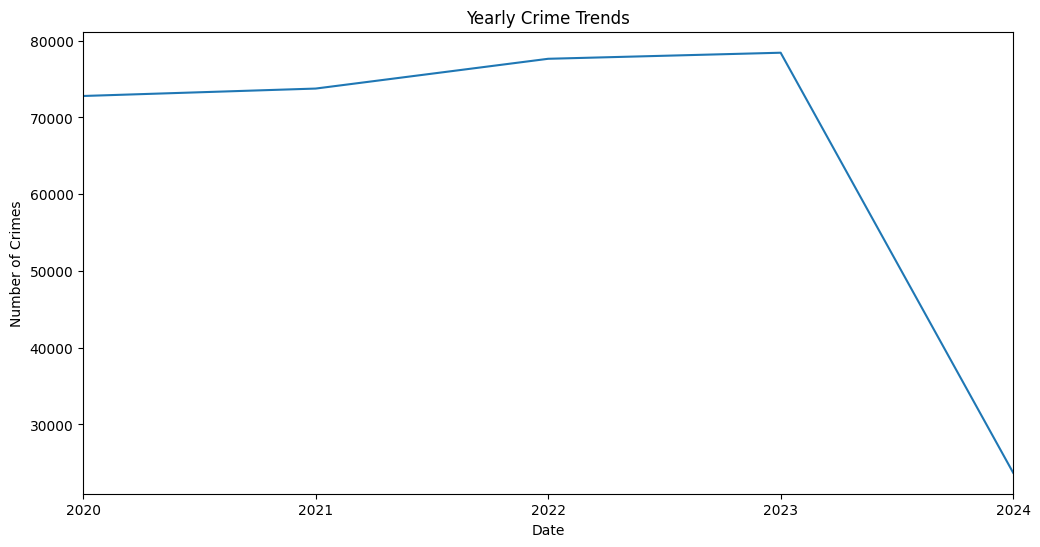

In [ ]:
# Monthly Crime Trends
monthly_crime_counts = df.groupby(df['DATE OCC'].dt.to_period('M')).size()
monthly_crime_counts.index = monthly_crime_counts.index.to_timestamp()
plt.figure(figsize=(12, 6))
monthly_crime_counts.plot()
plt.title('Monthly Crime Trends')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()

# Yearly Crime Trends
yearly_crime_counts = df.groupby(df['DATE OCC'].dt.to_period('Y')).size()
yearly_crime_counts.index = yearly_crime_counts.index.to_timestamp()
plt.figure(figsize=(12, 6))
yearly_crime_counts.plot()
plt.title('Yearly Crime Trends')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()

#### Moving Average Smoothing

/tmp/ipykernel_8537/92284675.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size()


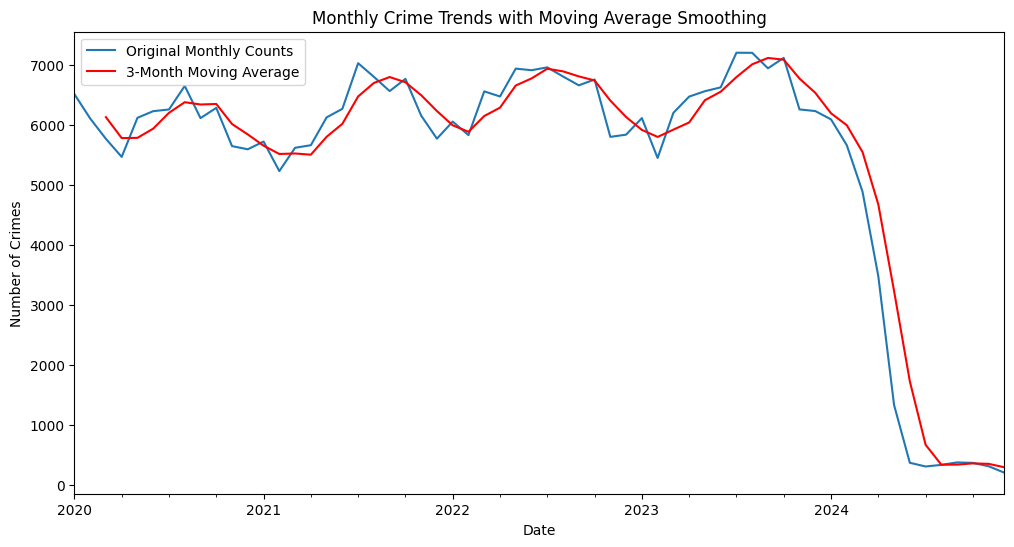

In [ ]:
monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size()

# Apply moving average (e.g., 3-month rolling mean)
moving_avg = monthly_crime_counts_resampled.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
monthly_crime_counts_resampled.plot(label='Original Monthly Counts')
moving_avg.plot(label='3-Month Moving Average', color='red')
plt.title('Monthly Crime Trends with Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.legend()
plt.show()

#### Seasonal Decomposition

/tmp/ipykernel_8537/3395836757.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size().fillna(0)


<Figure size 1400x800 with 0 Axes>

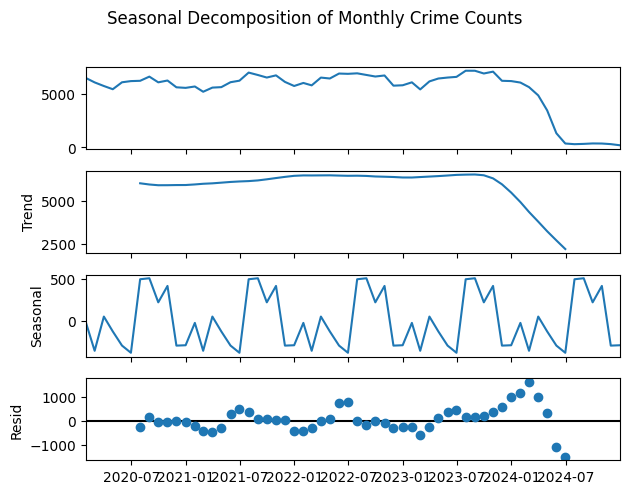

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the time series has sufficient data points for decomposition
# For monthly data, need at least 2 full cycles (e.g., 24 months for yearly seasonality)

# Re-index monthly_crime_counts_resampled to ensure proper frequency for decomposition
monthly_crime_counts_resampled = df.set_index('DATE OCC').resample('M').size().fillna(0)

# Check for minimum length for decomposition
if len(monthly_crime_counts_resampled) >= 24: # Assuming yearly seasonality (12 data points)
    decomposition = seasonal_decompose(monthly_crime_counts_resampled, model='additive', period=12) # Assuming yearly seasonality

    plt.figure(figsize=(14, 8))
    decomposition.plot()
    plt.suptitle('Seasonal Decomposition of Monthly Crime Counts', y=1.02) # Adjust suptitle position
    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough data points ({len(monthly_crime_counts_resampled)}) for seasonal decomposition. Requires at least 24 data points for yearly seasonality.")